# 02. The Detective's Notebook: Finding Contradictions

In **Notebook 01**, the Mayor presented a terrifying 6-graph report showing that drivers over 65 have the highest accident rates and severe hospitalizations. The executive order to revoke their licenses is sitting on the desk.

If we were purely predictive Data Scientists, we might agree with the Mayor. The data clearly shows a *correlation* between Age and Accidents. 

However, we are **Causal Inferentialists**. We know that **Correlation does not imply Causation**. A correlation simply means two variables move together; causation means one actively triggers the other. If Age *causes* accidents, banning old people will save lives. But what if Age is just correlated with accidents because of a third, hidden factor? If we ban the elderly, we might miss the real root cause entirely.

Our job is to act as detectives. We must look for logical contradictions in the Mayor's simplistic theory. Let's load the data and use advanced visualizations to find the cracks in the Mayor's argument.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
df = pd.read_csv('smart_city_road_safety_synthetic_5000.csv')

bins = [18, 35, 55, 70, 100]
labels = ['18-35 (Young)', '36-55 (Adult)', '56-70 (Senior)', '71+ (Elderly)']
df['Age_Group'] = pd.cut(df['Driver_Age'], bins=bins, labels=labels, right=False)

## Contradiction 1: The Compensatory Paradox (Hexbin JointPlot)
If older drivers inherently cause more accidents, one would assume they are driving recklessly fast or aggressively. Let's look at the density of driving speeds across different ages.

We will use a **Hexbin JointPlot**. This plot is excellent for large datasets because instead of overlapping thousands of dots (which creates a messy blob), it bins the data into hexagons and colors them based on density. The darker the green, the more drivers fall into that exact Age and Speed combination.

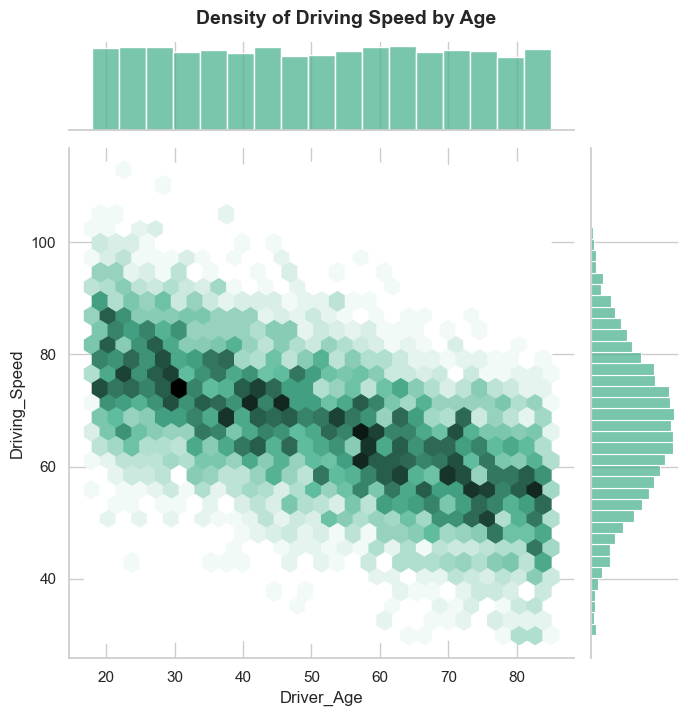

In [2]:
g = sns.jointplot(data=df, x='Driver_Age', y='Driving_Speed', kind="hex", color="#4CB391", height=7)
g.fig.suptitle("Density of Driving Speed by Age", y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 🕵️‍♂️ The Detective's Insight:
**Wait a minute!** Look at the dark green clusters. 
- The densest cluster for young people (age 20-30) is around **75-80 km/h**.
- For the elderly (age 70+), the densest cluster drops all the way down to **60-65 km/h**.

Older drivers actually drive significantly *slower*. This is known as **Compensatory Behavior**. As humans age and realize their reflexes are slowing down, they subconsciously compensate by driving more cautiously.

Here is the logical paradox: We know from basic physics that driving slower *reduces* accidents. So, if the elderly are driving at the safest speeds in the city, **why do they have the highest accident rates?**

There must be a missing variable. The Age itself isn't causing the crashes; something else associated with Age is overpowering their safe driving habits.

## Contradiction 2: The Hidden Root Cause (Regression LMPlot)
Let's investigate another variable in our dataset: `Vision_Quality` (measured from 0 to 100, where 100 is perfect 20/20 vision).

Does vision explain the accidents better than age? We will plot Age against Vision Quality, but we will split the data: Green dots for Safe Drivers, and Red crosses for those who crashed. We will also fit a linear regression line to see the trend.

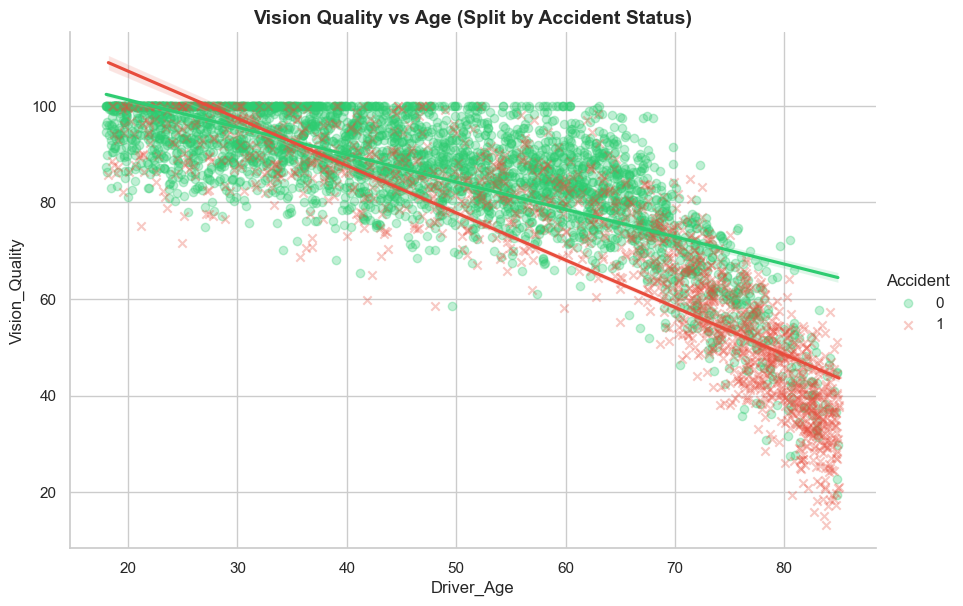

In [3]:
sns.lmplot(data=df, x='Driver_Age', y='Vision_Quality', hue='Accident', 
           palette=['#2ecc71', '#e74c3c'], markers=['o', 'x'], scatter_kws={'alpha':0.3}, aspect=1.5, height=6)
plt.title("Vision Quality vs Age (Split by Accident Status)", fontsize=14, fontweight='bold')
plt.show()

### 🕵️‍♂️ The Detective's Insight:
**Ah! The smoking gun!**

Look at where the red crosses (Accidents) are clustered. They are almost exclusively clustered at the **bottom** of the Y-axis (Low Vision Quality). It barely matters what your age is on the X-axis; if your vision drops below 70, you are highly likely to crash.

What the Mayor's naive report detected was a **Spurious Correlation** (Omitted Variable Bias). 
1. As people age, their vision naturally degrades.
2. Poor vision directly causes car crashes.
3. Therefore, the data makes it *look* like Age causes crashes, but Age is merely a proxy for Vision.

If this is true, revoking licenses based purely on *age* is terrible public policy. It discriminates against an 80-year-old with perfect vision (or good glasses) while ignoring a 40-year-old who desperately needs an eye exam. A better policy would be **mandating strict vision tests for all drivers**.

## Setting up the Final Piece: The Precision Variable
We need one more variable to build robust statistical models: something that causes accidents, but has absolutely nothing to do with Age. 

In econometrics, this is called a **Precision Variable**. Adding it to a model won't change our causal conclusions about Age, but it will reduce the "noise" in our math, making our confidence intervals tighter.

Let's verify that `Weather` affects all ages equally.

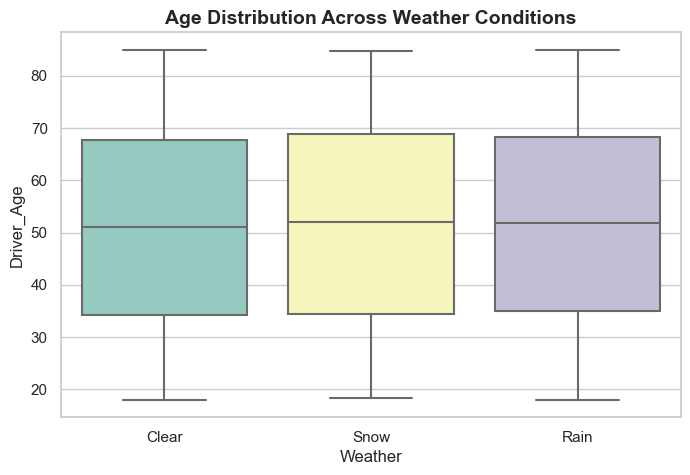

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather', y='Driver_Age', palette='Set3')
plt.title("Age Distribution Across Weather Conditions", fontsize=14, fontweight='bold')
plt.show()

Perfect. The median age (the line inside the box) is identical across Clear, Rain, and Snow. Your age does not control whether it rains today! This confirms Weather is completely independent of the "Treatment" (Age).

---
## Conclusion: We Need a Causal Map

We cannot answer the Mayor's policy question using simple `groupby` operations anymore. We have uncovered a tangled web of cause and effect:
- **Age** affects **Speed** (which *reduces* accidents).
- **Age** affects **Vision** (which *increases* accidents).
- **Age** affects **Hospitalization** fragility (making the severity data look scarier than the crash rate).

If we just throw all these variables into a Machine Learning model or a Naive Regression, the math will be hopelessly confused by these overlapping paths. 

Before we write a single line of predictive code, we must draw our assumptions mathematically using **Directed Acyclic Graphs (DAGs)**. Let's move to **Notebook 03** to draw our maps!